**The Tabular value-fucntion methods on the cart and pole system**

Consider the cart-and-pole system here depicted:
<div>
<img src="https://drive.google.com/uc?export=view&id=1Yu5zZ57OEEYZ678yWLaU7h-Wq3M9vV9E" width="200">
</div>
whose dynamics follows the following equations:

\begin{align}
  \ddot{\theta}&=\frac{g \sin(\theta)\,+\,\cos(\theta) \left[ \frac{-F\,-\,m_p\,l\,\dot{\theta}^2 \sin \left(\theta\right)}{m_c\,+\,m_p}\right]-\frac{\mu_p\dot{\theta}}{m_p\,l}}{l\,\left[\frac{4}{3}-\frac{m_p\,cos^2\left(\theta\right)}{m_c\,+\,m_p}\right]}
\end{align}
>>>>>>>>>>>>>>>>>>>>>>>>$(*)$

\begin{align}
  \ddot{p}_c&=\frac{F\,+\,m_p\,l\,\left[\dot{\theta}^2\,\sin\left(\theta\right)\,-\,\ddot{\theta}\,\cos(\theta)\right]}{m_c\,+\,m_p}
\end{align}

where $g = 9.8\,\text{m/sec}$ is the gravitational acceleration, $m_c = 1\,\text{kg}$ is the cart mass, $m_p = 0.1\,\text{kg}$ is the pole mass, $l = 0.5\,\text{m}$ is the half-pole length, $\mu_p = 0.000002$ is the pole on cart friction coefficient.

In [1]:
import numpy as np
from scipy.integrate import solve_ivp, odeint
from numpy import linalg as LA
import matplotlib.pyplot as plt
from scipy.io import loadmat
import jax.numpy as jnp
from jax import jacfwd
from jax import config
from scipy.optimize import fsolve
from IPython.display import HTML, clear_output
import matplotlib.animation as animation
from matplotlib import rc
import matplotlib
from tqdm import tqdm

matplotlib.rcParams['animation.embed_limit'] = 2**128
rc('animation', html='jshtml')
config.update("jax_enable_x64", True)

In [2]:
class InvertedPendulum:
  def __init__(self, m_c, m_p, g, l, u_p):
    self.m_c = m_c
    self.m_p = m_p
    self.g = g
    self.l = l
    self.u_p = u_p

  ############################################################################
  ## Computation of the non-linear system
  ############################################################################

  def compute(self, t, x: np.array, u: float) -> tuple:
    dx = [None for _ in range(4)]
    dx[0] = x[1]
    dx[1] = (self.g*jnp.sin(x[0]) + jnp.cos(x[0])*((-u -self.m_p*self.l*jnp.sin(x[0])*x[1]**2)/(self.m_c + self.m_p)) - (self.u_p*x[1])/(self.m_p*self.l))/(self.l*(4/3 - (self.m_p*jnp.cos(x[0])**2)/(self.m_c + self.m_p)))
    dx[2] = x[3]
    dx[3] = (u + self.m_p*self.l*(jnp.sin(x[0])*x[1]**2 - dx[1]*jnp.cos(x[0])))/(self.m_c + self.m_p)

    dx = jnp.asarray(dx)

    return dx



  def render_cart_pole(self, time: float, state_evolution: np.array, sample_time: float):
    fig, ax = plt.subplots()

    cart_position = state_evolution[2, :]
    pole_angle = state_evolution[0, :]

    cart_width = 0.3
    cart_height = 0.2

    cart = plt.Rectangle((cart_position[0] - cart_width/2, 0), cart_width, cart_height, color='blue')
    pole_length = self.l*2
    pole = plt.Line2D([cart_position[0], cart_position[0] + pole_length*np.sin(pole_angle[0])],
                     [cart_height, cart_height + pole_length*np.cos(pole_angle[0])], color='black', linewidth=2)
    ax.set(xlim=[-2, 2], ylim=[-2, 2], xlabel='Position X [m]', ylabel='Position Y [m]')

    ax.grid()

    ax.add_patch(cart)
    ax.add_line(pole)

    def update(frame):
      cart.set_x(cart_position[frame] - cart_width/2)
      pole.set_data([cart_position[frame], cart_position[frame] + pole_length*np.sin(pole_angle[frame])],
                     [cart_height, cart_height + pole_length*np.cos(pole_angle[frame])])
      return (cart, pole)


    ani = animation.FuncAnimation(fig=fig, func=update, frames=state_evolution.shape[1], interval=sample_time*1000)
    plt.close()

    return ani

In [3]:
def plot_solutions(t, solutions):
  # Create a figure with 2x2 subplots
  fig, axes = plt.subplots(1, 2, figsize=(10, 3))
  # Subplot 1 (left)
  axes[0].plot(t, solutions[0, :], label=r'theta')
  axes[0].set_title(r'$\theta(t)$')
  axes[0].legend()
  # Subplot 2 (right)
  axes[1].plot(t, solutions[0, :], label='theta')
  axes[1].plot(t, solutions[1, :], label='d(theta)')
  axes[1].plot(t, solutions[2, :], label='p')
  axes[1].plot(t, solutions[3, :], label='d(p)')
  axes[1].set_title(r'$\theta(t)$, $\dot{\theta}(t)$, $p(t)$, $\dot{p}(t)$')
  axes[1].legend()
  # Adjust layout
  plt.tight_layout()
  # Show the plot
  plt.show()

In [4]:
inv_pend = InvertedPendulum(m_c=1, m_p=0.1, g=9.8, l=0.5, u_p=0.000002)

1. Given the $X$ set, select centers and standard deviation of RBFs and create a code that given a state $x$ returns $\phi\left(x,\cdot\right)$.

In [5]:
space_non_terminal_intervals = [
    (-.2095, .2095),
    (-2, 2),
    (-2.4, 2.4),
    (-2, 2)
]

In [6]:
inputs = np.asarray([-10, 10])
episodes = 10000

weights = np.zeros((4, len(inputs)))
weights

array([[0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.]])

In [7]:
def rbf_func(state, means, stds):
  return np.exp(- (1/(2*stds**2)) * ((state - means)**2))

means = np.zeros(4)
stds = np.ones(4)*2/3

rbf_func(state=np.array([np.pi/13, 0, 0.2, 0]), means=means, stds=stds)

array([0.93641172, 1.        , 0.95599748, 1.        ])

In [8]:
def q_func(state, input):
  input_idx = np.argmin(np.abs(input - inputs))
  return np.dot(weights[:, input_idx], rbf_func(state, means=means, stds=stds))

q_func(state=np.array([np.pi/13, 0, 0.2, 0]), input=-10)

0.0

In [9]:
def epsilon_greedy_policy(epsilon, state):
  greedy_vs_explore = np.random.uniform(0,1)
  if greedy_vs_explore > epsilon: # Exploiting
    u = max(inputs, key=lambda input: q_func(state, input))
  else: # Exploring
    u = inputs[np.random.randint(len(inputs))]
  return u

epsilon_greedy_policy(0.2, np.array([np.pi/13, 0, 0.2, 0]))

-10

In [10]:
MAX_ITERS = 1000

def compute_reward(state, iter):
  reward = 1

  if iter > MAX_ITERS:
    reward = 0
  elif abs(state[2]) > 2.4:
    reward = 0
  elif abs(state[0]) > 0.2095:
    reward = 0

  return reward

compute_reward(np.array([np.pi/13, 0, 0.2, 0]), 0)

0

In [11]:
def greedy_policy(state):
  return max(inputs, key=lambda input: q_func(state, input))

greedy_policy(np.array([np.pi/13, 0, 0.2, 0]))

-10

In [12]:
def random_state():
  state = [np.random.uniform(low=space_non_terminal_intervals[i][0], high=space_non_terminal_intervals[i][1]) for i in range(len(space_non_terminal_intervals))]
  return np.asarray(state)

random_state()

array([ 0.10366333,  1.32839081, -0.68231502,  0.95837883])

In [13]:
def q_learning(alpha, gamma):
  for episode in tqdm(range(episodes)):

    x_init = random_state()

    done = False
    iter = 0

    while not done:
      u = epsilon_greedy_policy(0.2, x_init)
      u_idx = np.argmin(np.abs(inputs - u))

      sol = solve_ivp(fun=lambda t, x: inv_pend.compute(t, x, u), t_span=[0, 0.02], y0=x_init, t_eval=[0, 0.02], method='RK45', rtol=1e-3, atol=1e-6)
      sol = sol.y[:, 1]

      reward = compute_reward(sol, iter)

      fq_estim = q_func(sol, max(inputs, key=lambda input: q_func(sol, input)))

      done = reward != 1

      if not done:
        gradient = rbf_func(x_init, means=means, stds=stds)
        weights[:, u_idx] = weights[:, u_idx] + \
                                np.dot(alpha*(reward + gamma*fq_estim - q_func(x_init, u_idx)), gradient)

      x_init = sol

      iter += 1


In [14]:
q_learning(alpha=0.01, gamma=0.99)

100%|██████████| 10000/10000 [28:03<00:00,  5.94it/s]


In [15]:
def simulate(x_init, simulation_time, sample_time):
  t_eval = np.linspace(0, simulation_time, int(simulation_time/sample_time) + 1)
  result = np.empty((x_init.shape[0], t_eval.shape[0]))
  result[:, 0] = x_init

  u_seq = np.empty(t_eval.shape[0] - 1)

  # simulation
  for i in range(0, t_eval.shape[0] - 1):
    tspan = [t_eval[i], t_eval[i + 1]]

    u = greedy_policy(x_init)
    u_seq[i] = u

    sol = solve_ivp(fun=lambda t, x: inv_pend.compute(t, x, u), t_span=tspan, y0=x_init, t_eval=tspan, method='RK45', rtol=1e-3, atol=1e-6)
    x_init = sol.y[:, 1]

    result[:, i+1] = x_init
  return (t_eval, result, u_seq)

In [16]:
t_s1, states_s1, u_seq = simulate(x_init=np.array([np.pi/13, 0, 0.01, 0]), simulation_time = 5, sample_time=0.02)

In [17]:
u_seq, weights

(array([ 10.,  10.,  10.,  10.,  10.,  10., -10.,  10., -10.,  10., -10.,
         10., -10.,  10., -10.,  10., -10.,  10., -10.,  10., -10.,  10.,
        -10.,  10., -10.,  10., -10.,  10., -10.,  10., -10.,  10., -10.,
         10., -10.,  10.,  10., -10.,  10., -10.,  10., -10.,  10.,  10.,
        -10.,  10.,  10., -10.,  10.,  10., -10.,  10.,  10.,  10., -10.,
         10., -10.,  10.,  10., -10.,  10., -10.,  10., -10.,  10., -10.,
         10., -10.,  10., -10.,  10., -10.,  10.,  10., -10.,  10., -10.,
         10.,  10., -10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,
         10.,  10.,  10.,  10.,  10.,  10.,  10.,  10., -10.,  10.,  10.,
        -10.,  10., -10.,  10., -10.,  10., -10.,  10., -10., -10., -10.,
         10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10., -10.,  10.,
         10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,
         10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,
         10.,  10.,  10.,  10.,  10., 

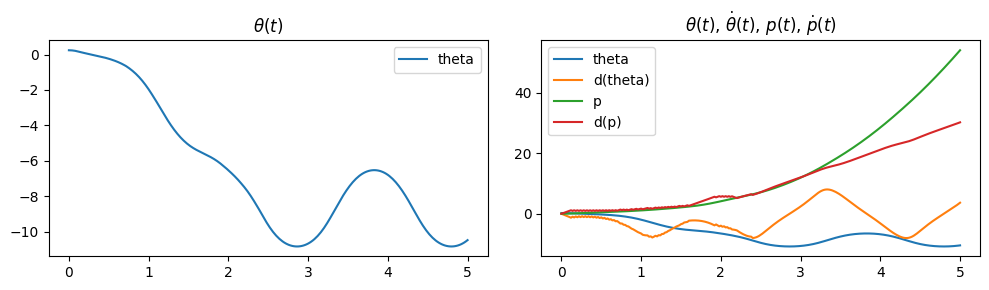

In [18]:
plot_solutions(t_s1, states_s1)

In [19]:
inv_pend.render_cart_pole(t_s1, states_s1, 0.02)

Output hidden; open in https://colab.research.google.com to view.

*Provide the code*:











































2. Create a code that applies Q-Learning algorithm with function approximation


*Provide the code*:



3. Copy and paste your Q-learning algorithm with function approximation and apply the changes needed to convert it into a SARSA algorithm with function approximation


In [ ]:
weights = np.zeros((4, len(inputs)))
weights

In [ ]:
rewards = []

def sarsa_learning(alpha, gamma):
  for episode in tqdm(range(episodes)):

    x_init = random_state()

    done = False
    iter = 0

    u = epsilon_greedy_policy(0.2, x_init)
    u_idx = np.argmin(np.abs(inputs - u))

    episode_reward = 0

    while not done:

      sol = solve_ivp(fun=lambda t, x: inv_pend.compute(t, x, u), t_span=[0, 0.02], y0=x_init, t_eval=[0, 0.02], method='RK45', rtol=1e-3, atol=1e-6)
      sol = sol.y[:, 1]

      u_new = epsilon_greedy_policy(0.2, sol)
      u_new_idx = np.argmin(np.abs(inputs - u))

      reward = compute_reward(sol, iter)

      episode_reward += reward

      done = reward != 1

      if not done:
        gradient = rbf_func(x_init, means=means, stds=stds)
        weights[:, u_idx] = weights[:, u_idx] + \
                                np.dot(alpha*(reward + gamma*q_func(sol, u_new) - q_func(x_init, u_idx)), gradient)

      x_init = sol
      u = u_new
      u_idx = u_new_idx

      iter += 1

    rewards.append(episode_reward/iter)

In [ ]:
sarsa_learning(0.01, 0.99)

In [ ]:
plt.plot(rewards)

In [ ]:
t_s2, states_s2, u_seq_2 = simulate(x_init=np.array([np.pi/13, 0, 0.01, 0]), simulation_time = 5, sample_time=0.02)

In [ ]:
plot_solutions(t_s2, states_s2)

In [ ]:
u_seq, weights

In [ ]:
inv_pend.render_cart_pole(t_s2, states_s2, 0.02)

*Provide the code*: